# Thermal Data Collection

Derive the Mars coordinates of every image in `data/final_data/image_dataset.json`
and turn them into a THEMIS retrieval plan, saved under `data/thermal_data/`.

The pipeline this feeds:

1. **This notebook** — image -> centre latitude/longitude -> deduplicated query sites.
2. **`themis_measurements.py`** (Phase 1) — site -> THEMIS observation IDs covering it,
   with acquisition time and Mars local solar time.
3. **`themis_id_to_thermal_value.py`** (Phase 2) — observation ID -> decoded
   brightness-temperature matrix (`.npy`).

The model consumes a small window at **native THEMIS resolution (~100 m/pixel)**,
not a raster upsampled to the HiRISE grid, so what we need per site is a
`32 x 32` THEMIS patch per timestep rather than a full-resolution image.

In [8]:
%load_ext autoreload
%autoreload 2

import os
import sys

# This notebook lives two levels down (data/thermal/), so put the repo root on
# the path and anchor every location to it -- that way the paths hold whatever
# directory Jupyter was started from.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from data.coordinates import center_latlon, ground_extent_m, THEMIS_GSD_M

DATA_PATH = os.path.join(REPO_ROOT, "data")
DATASET_JSON = os.path.join(DATA_PATH, "optical", "final_data", "image_dataset.json")

THERMAL_DIR = os.path.join(DATA_PATH, "thermal")
THEMIS_DIR = os.path.join(THERMAL_DIR, "themis_data")        # real THEMIS products
GENERATED_DIR = os.path.join(THERMAL_DIR, "generated_data")  # synthetic thermal

os.makedirs(THEMIS_DIR, exist_ok=True)

print("Repo root    :", REPO_ROOT)
print("THEMIS output:", THEMIS_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root    : C:\Users\Utente\Desktop\lavatube_paper
THEMIS output: C:\Users\Utente\Desktop\lavatube_paper\data\thermal\themis_data


## 1. Load the training dataset

These are the same rows the model trains on, so every image gets a coordinate.

In [9]:
image_data = pd.read_json(DATASET_JSON)

class_names = {
    0: "Vertical Pit/Skylight",
    1: "Shallow Pit Chain",
    2: "Sloped Pit",
    3: "Plain Terrain",
}

print(f"{len(image_data)} images")
print(image_data["category_id"].map(class_names).value_counts().to_string())

1560 images
category_id
Plain Terrain            780
Vertical Pit/Skylight    359
Shallow Pit Chain        275
Sloped Pit               146


## 2. Coordinates

`image_dataset.json` already carries `lat`, `lon_east` and each crop's ground
extent, all computed once when the two source datasets were merged in
`data_overview.ipynb`. Nothing here needs to touch a raster.

Those coordinates come from `themis_coordinates.center_latlon`, which reads each
crop's own georeferencing and repairs a malformed CRS present in the
plain-terrain products: the standard parallel was written into
`latitude_of_origin` with `standard_parallel_1` left at 0, a known planetary-PDS
quirk. Read literally, that offsets latitude by exactly the standard parallel
(up to 45 deg here, ~2600 km) and mis-scales longitude. Section 3 validates the
repair against independently derived values.

If an older `image_dataset.json` without those columns is loaded, the cell falls
back to reading the rasters (slow: a couple of minutes for ~2400 files).

In [10]:
PRECOMPUTED = ["lat", "lon_east", "ground_width_m", "ground_height_m"]
has_coords = set(PRECOMPUTED).issubset(image_data.columns)

if has_coords:
    print("Using precomputed coordinates and extents from image_dataset.json")
    coordinates = image_data[
        ["image_name", "img_path", "category_id", *PRECOMPUTED]
    ].copy()
else:
    print("Columns missing -- recomputing from the rasters "
          "(re-run data_overview.ipynb to avoid this)")
    records = []
    for row in tqdm(
        image_data.itertuples(index=False),
        total=len(image_data),
        desc="Reading georeferencing",
    ):
        path = os.path.join(row.img_path, row.image_name)
        lat, lon = center_latlon(path)
        width_m, height_m = ground_extent_m(path)
        records.append({
            "image_name": row.image_name,
            "img_path": row.img_path,
            "category_id": row.category_id,
            "lat": lat,
            "lon_east": lon,
            "ground_width_m": width_m,
            "ground_height_m": height_m,
        })
    coordinates = pd.DataFrame(records)

coordinates["themis_px_across"] = coordinates["ground_width_m"] / THEMIS_GSD_M
coordinates.head()

Using precomputed coordinates and extents from image_dataset.json


,image_name,img_path,category_id,lat,lon_east,ground_width_m,ground_height_m,themis_px_across
0,ESP_011386_2065_RED_resized_2_lbl_0_pos.tiff,data/optical/matched_pairs,0,26.148829,259.342960,808.105208,808.000000,8.081052
1,ESP_011386_2065_RED_resized_2_lbl_0_neg.tiff,data/optical/matched_pairs,3,26.159030,259.342960,808.105208,808.000000,8.081052
2,ESP_011386_2065_RED_resized_2_lbl_1_pos.tiff,data/optical/matched_pairs,1,26.124290,259.347414,770.100260,770.000000,7.701003
3,ESP_011386_2065_RED_resized_2_lbl_1_neg.tiff,data/optical/matched_pairs,3,26.135065,259.347414,770.100260,770.000000,7.701003
4,ESP_011386_2065_RED_resized_3_lbl_0_pos.tiff,data/optical/matched_pairs,0,26.148822,259.342951,1605.208984,1605.184165,16.052090


### On validating these coordinates

`center_latlon` repairs a malformed CRS found in some HiRISE products, where the
standard parallel was written into `latitude_of_origin` while
`standard_parallel_1` was left at 0. Read literally that offsets latitude by
exactly the standard parallel -- errors of 35, 5, 45 and 15 degrees were measured
across products, up to roughly 2600 km on the ground.

The repair was validated against 528 plain-terrain crops that carried
independently derived coordinates, computed from the source PDS label bounds
rather than from projection maths: every Equirectangular product matched to
0.0000 deg, and the two Polar Stereographic products differed by at most
0.38 deg, which is the label-derived value being the coarser approximation near
the poles.

Those crops have since been replaced by the matched pairs, so the check no
longer runs here. The current crops inherit the DeepLandforms CRS, which is
correct as written; the repair stays in place for products that need it.

## 4. How much thermal signal is actually there?

At \~100 m/pixel a HiRISE crop covers only a handful of THEMIS samples. This is
why the thermal stream gets its own small encoder instead of sharing the HiRISE
backbone, and why we extract a fixed window around each site rather than
matching the crop's exact footprint: a fixed `32 x 32` window (\~3.2 km) is a
consistent tensor shape and includes surrounding terrain, which is what makes
the pit-versus-background temperature contrast measurable.

In [11]:
spans = coordinates["themis_px_across"]

print("THEMIS pixels across a crop:")
print(f"  min    {spans.min():6.1f}")
print(f"  median {spans.median():6.1f}")
print(f"  max    {spans.max():6.1f}")
print()
print(f"Crops smaller than one THEMIS pixel: {(spans < 1).sum()}")
print(f"Fixed extraction window: 32 x 32 THEMIS px "
      f"= {32 * THEMIS_GSD_M / 1000:.1f} x {32 * THEMIS_GSD_M / 1000:.1f} km")

THEMIS pixels across a crop:
  min       3.9
  median    9.8
  max      25.6

Crops smaller than one THEMIS pixel: 0
Fixed extraction window: 32 x 32 THEMIS px = 3.2 x 3.2 km


## 5. Deduplicate into query sites

Crops closer together than a THEMIS pixel resolve to the same thermal data, and
many crops are multi-resolution replicas of the same landform. Grouping them
onto a coarse grid collapses the number of network queries substantially --
Phase 1 and Phase 2 both hit remote archives, so this matters.

The grid step below is half the extraction window, so any two crops sharing a
site also share almost all of their thermal window.

In [12]:
GRID_DEG = 0.05  # ~3 km at the equator, about half the 32-px window

coordinates["site_lat"] = (coordinates["lat"] / GRID_DEG).round() * GRID_DEG
coordinates["site_lon"] = (coordinates["lon_east"] / GRID_DEG).round() * GRID_DEG

query_sites = (
    coordinates
    .groupby(["site_lat", "site_lon"], as_index=False)
    .agg(
        n_images=("image_name", "size"),
        categories=("category_id", lambda s: sorted(set(s))),
    )
    .sort_values(["site_lat", "site_lon"])
    .reset_index(drop=True)
)

query_sites["site_id"] = [f"site_{i:04d}" for i in range(len(query_sites))]

print(f"{len(coordinates)} images -> {len(query_sites)} unique query sites")
query_sites.head()

1560 images -> 233 unique query sites


,site_lat,site_lon,n_images,categories,site_id
0,-21.30,239.35,9,"[2, 3]",site_0000
1,-21.30,239.40,3,[3],site_0001
2,-21.25,239.35,17,"[2, 3]",site_0002
3,-21.25,239.40,11,"[1, 3]",site_0003
4,-21.20,239.35,3,[3],site_0004


## 6. Save the retrieval manifest

* `data/thermal_data/image_coordinates.csv` — one row per training image, with
  its site assignment. This is what the dataset loader will use to find the
  right thermal window, and it serves the synthetic pipeline in
  `generated_data/` equally well.
* `data/thermal_data/themis_data/themis_query_sites.csv` — the deduplicated
  sites to actually query.

In [13]:
# map every image to the site that will hold its thermal data
site_lookup = query_sites.set_index(["site_lat", "site_lon"])["site_id"]
coordinates["site_id"] = coordinates.set_index(["site_lat", "site_lon"]).index.map(site_lookup)

coord_path = os.path.join(THERMAL_DIR, "image_coordinates.csv")
sites_path = os.path.join(THEMIS_DIR, "themis_query_sites.csv")

coordinates.to_csv(coord_path, index=False)
query_sites.to_csv(sites_path, index=False)

print("Saved:")
print(" ", coord_path, f"({len(coordinates)} rows)")
print(" ", sites_path, f"({len(query_sites)} rows)")

Saved:
  C:\Users\Utente\Desktop\lavatube_paper\data\thermal\image_coordinates.csv (1560 rows)
  C:\Users\Utente\Desktop\lavatube_paper\data\thermal\themis_data\themis_query_sites.csv (233 rows)


## 7. Phase 1 — find THEMIS observations per site

`themis_measurements.py` queries the ODE ArcGIS IRPBT4 footprint layer for one
point and returns the observations covering it, with acquisition time and Mars
local solar time. Local solar time is the useful axis here: the diagnostic
signal for a cave-connected pit is that it stays anomalously warm at night, so a
sequence spanning different times of day is what the temporal model needs.

**These are live network calls to an external archive.** The loop is disabled by
default -- set `RUN_PHASE_1 = True` to actually fetch, and consider starting with
`query_sites.head(...)` rather than the full set.

In [14]:
from data.thermal.themis_measurements import query_point, build_records

RUN_PHASE_1 = True          # set True to hit the network
SITES_TO_QUERY = query_sites  # e.g. query_sites.head(5) for a trial run

observations_path = os.path.join(THEMIS_DIR, "themis_observations.csv")

if RUN_PHASE_1:
    found = []

    for site in tqdm(
        SITES_TO_QUERY.itertuples(index=False),
        total=len(SITES_TO_QUERY),
        desc="Phase 1: footprint queries",
    ):
        try:
            payload = query_point(site.site_lat, site.site_lon)
            for record in build_records(payload, site.site_lon):
                record["site_id"] = site.site_id
                record["site_lat"] = site.site_lat
                record["site_lon"] = site.site_lon
                found.append(record)
        except Exception as exc:
            print(f"  {site.site_id} failed: {exc}")

    observations = pd.DataFrame(found)
    observations.to_csv(observations_path, index=False)
    print(f"\n{len(observations)} observations across "
          f"{observations['site_id'].nunique()} sites -> {observations_path}")
else:
    print("Phase 1 skipped (RUN_PHASE_1 is False).")
    if os.path.exists(observations_path):
        observations = pd.read_csv(observations_path)
        print(f"Loaded {len(observations)} previously saved observations.")
    else:
        observations = pd.DataFrame()
        print("No saved observations yet.")

Phase 1: footprint queries: 100%|██████████| 233/233 [03:04<00:00,  1.26it/s]


1921 observations across 232 sites -> C:\Users\Utente\Desktop\lavatube_paper\data\thermal\themis_data\themis_observations.csv


### What local solar times are actually available?

The diagnostic signal for a cave-connected pit is that it stays anomalously warm
at night, so what the temporal branch needs is *contrast across time of day*.

Do not assume a tidy midday / morning / midnight triple is obtainable. Mars
Odyssey flies a near sun-synchronous orbit, so a given site is revisited near
only a couple of local solar times -- broadly a day pass and a night pass about
12 h apart -- with that local time drifting slowly over the mission rather than
sweeping the whole diurnal cycle. Check the real distribution before choosing a
sequence policy.

In [15]:
if len(observations):
    lmst = observations["mars_lmst_decimal_hours"].dropna()

    counts, _ = np.histogram(lmst, bins=24, range=(0, 24))
    print("Observations by Mars local solar time (all sites):")
    for hour, count in enumerate(counts):
        if count:
            print(f"  {hour:02d}:00  {'#' * min(count, 60)} {count}")

    per_site_span = (
        observations.groupby("site_id")["mars_lmst_decimal_hours"]
        .agg(lambda s: s.max() - s.min())
    )
    print(f"\nLocal-time span within a site: median {per_site_span.median():.1f} h, "
          f"max {per_site_span.max():.1f} h")
else:
    print("Run Phase 1 first.")

Observations by Mars local solar time (all sites):
  03:00  ############################ 28
  04:00  ################################# 33
  06:00  ############################################################ 943
  15:00  ######################################## 40
  16:00  ############################################### 47
  18:00  ############################################################ 830

Local-time span within a site: median 12.2 h, max 14.9 h


### Choosing a sequence per site

Rather than targeting fixed clock hours that may not exist, this picks the `T`
observations that are maximally separated on the 24 h circle (greedy
farthest-point selection). That extracts whatever diurnal contrast a site
genuinely offers -- a day/night pair when that is all there is, a wider spread
when more exists -- and degrades gracefully instead of silently returning three
near-identical frames.

Frames are then ordered by local solar time so the TCN sees a coherent
progression rather than an arbitrary permutation.

In [16]:
SEQUENCE_LENGTH = 3  # must match Hirise_Dataset(sequence_length=...)


def circular_gap(a, b, period=24.0):
    """Shortest distance between two local-solar-time values, in hours."""
    diff = abs(a - b) % period
    return min(diff, period - diff)


def spread_over_local_time(group, n):
    """Pick n rows whose local solar times are as far apart as possible."""
    usable = group.dropna(subset=["mars_lmst_decimal_hours"])
    if len(usable) <= n:
        return usable.sort_values("mars_lmst_decimal_hours")

    hours = usable["mars_lmst_decimal_hours"].tolist()

    # Seed with the earliest pass, then repeatedly add the observation
    # furthest (in time-of-day) from everything already selected.
    picked = [int(np.argmin(hours))]
    while len(picked) < n:
        best = max(
            (i for i in range(len(hours)) if i not in picked),
            key=lambda i: min(circular_gap(hours[i], hours[j]) for j in picked),
        )
        picked.append(best)

    return usable.iloc[sorted(picked, key=lambda i: hours[i])]


if len(observations):
    chosen = (
        observations
        .groupby("site_id", group_keys=False)
        .apply(spread_over_local_time, n=SEQUENCE_LENGTH)
    )

    counts = chosen.groupby("site_id").size()
    print(f"Sites with a full sequence of {SEQUENCE_LENGTH}: "
          f"{(counts == SEQUENCE_LENGTH).sum()} / {len(counts)}")
    print(f"Sites with fewer (not enough passes): {(counts < SEQUENCE_LENGTH).sum()}")

    gaps = chosen.groupby("site_id")["mars_lmst_decimal_hours"].agg(
        lambda s: max(s) - min(s)
    )
    print(f"\nSelected local-time spread: median {gaps.median():.1f} h, "
          f"min {gaps.min():.1f} h, max {gaps.max():.1f} h")

    # Sites whose passes all land at one local time carry no diurnal contrast:
    # their frames are near-duplicates and the temporal branch has nothing to
    # learn from them. Worth excluding or flagging before training.
    flat = gaps[gaps < 0.5]
    print(f"Sites with effectively no diurnal contrast (<0.5 h spread): {len(flat)}")
    if len(flat):
        print(f"  e.g. {', '.join(flat.index[:5])}")

    display(chosen.head(10))
else:
    chosen = pd.DataFrame()
    print("Run Phase 1 first.")

Sites with a full sequence of 3: 217 / 232
Sites with fewer (not enough passes): 15

Selected local-time spread: median 12.1 h, min 0.0 h, max 14.8 h
Sites with effectively no diurnal contrast (<0.5 h spread): 17
  e.g. site_0023, site_0024, site_0025, site_0029, site_0030


C:\Users\Utente\AppData\Local\Temp\ipykernel_200152\536390225.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(spread_over_local_time, n=SEQUENCE_LENGTH)


,observation_id,product_id_raw,utc_start,utc_end,mars_lmst_decimal_hours,mars_lmst_hhmm,solar_longitude_deg,emission_angle_deg,incidence_angle_deg,phase_angle_deg,product_version,product_lid,ode_id,site_id,site_lat,site_lon
9,I92445021,i92445021pbt,2022-10-17T05:18:38.115Z,2022-10-17T05:22:37.580Z,6.5649,06:34,322.785,1.896,87.375,86.824,2.0,urn:nasa:pds:ody.themis.geo:data_irpbt:i924450...,48880512,site_0000,-21.30,239.35
0,I84259010,i84259010pbt,2020-12-12T04:38:35.068Z,2020-12-12T04:41:34.806Z,6.7155,06:43,329.985,2.200,87.545,87.026,2.1,urn:nasa:pds:ody.themis.geo:data_irpbt:i842590...,55288651,site_0000,-21.30,239.35
2,I89282002,i89282002pbt,2022-01-29T17:59:41.930Z,2022-01-29T18:00:42.196Z,18.5076,18:30,165.764,1.499,107.586,107.757,2.1,urn:nasa:pds:ody.themis.geo:data_irpbt:i892820...,55083600,site_0000,-21.30,239.35
20,IA1255015PBT,ia1255015pbt,2024-10-11T14:54:32.983Z,2024-10-11T14:56:32.983Z,6.3607,06:22,343.703,0.631,92.765,92.697,2.0,urn:nasa:pds:ody.themis.geo:data_irpbt:ia12550...,48647417,site_0001,-21.30,239.40
10,I84259010,i84259010pbt,2020-12-12T04:38:35.068Z,2020-12-12T04:41:34.806Z,6.7188,06:43,329.985,2.200,87.545,87.026,2.1,urn:nasa:pds:ody.themis.geo:data_irpbt:i842590...,55288651,site_0001,-21.30,239.40
18,I92177004,i92177004pbt,2022-09-25T03:00:08.785Z,2022-09-25T03:01:26.117Z,18.4488,18:27,310.121,1.399,77.998,78.515,2.0,urn:nasa:pds:ody.themis.geo:data_irpbt:i921770...,48864888,site_0001,-21.30,239.40
30,I92445021,i92445021pbt,2022-10-17T05:18:38.115Z,2022-10-17T05:22:37.580Z,6.5649,06:34,322.785,1.896,87.375,86.824,2.0,urn:nasa:pds:ody.themis.geo:data_irpbt:i924450...,48880512,site_0002,-21.25,239.35
21,I84259010,i84259010pbt,2020-12-12T04:38:35.068Z,2020-12-12T04:41:34.806Z,6.7155,06:43,329.985,2.200,87.545,87.026,2.1,urn:nasa:pds:ody.themis.geo:data_irpbt:i842590...,55288651,site_0002,-21.25,239.35
23,I89282002,i89282002pbt,2022-01-29T17:59:41.930Z,2022-01-29T18:00:42.196Z,18.5076,18:30,165.764,1.499,107.586,107.757,2.1,urn:nasa:pds:ody.themis.geo:data_irpbt:i892820...,55083600,site_0002,-21.25,239.35
40,I92445021,i92445021pbt,2022-10-17T05:18:38.115Z,2022-10-17T05:22:37.580Z,6.5682,06:34,322.785,1.896,87.375,86.824,2.0,urn:nasa:pds:ody.themis.geo:data_irpbt:i924450...,48880512,site_0003,-21.25,239.40


## 8. Phase 2 — extract the thermal windows

`themis_id_to_thermal_value.py` downloads a whole PBT product and decodes it to
a `.npy`. That is far more than this pipeline needs: products run 0.4-126 MB
(median 22 MB) and the model uses a 32x32 patch, about 4 KB. The 312 products
behind a T=3 sequence cost roughly 7 GB of cache plus 7 GB of decoded arrays.

The ASU archive supports HTTP range requests, so GDAL can open a product through
`/vsicurl/` and fetch only the bytes covering the window we want.
`themis_windows.read_window_for_observation` does that -- about 2 s per window,
a few megabytes in total instead of ~14 GB, and nothing cached locally.

Values are **brightness temperature in Kelvin**, with **0 meaning no data**
(not "very cold"). Mask it before computing any statistic.

This is also the step that produces the final arrays, so the separate
window-cutting stage the earlier draft deferred is no longer needed.

In [17]:
from data.thermal.themis_windows import read_window_for_observation, NODATA_KELVIN
from data.thermal.themis_id_to_thermal_value import ensure_index

RUN_PHASE_2 = True  # set True to fetch windows over the network
WINDOW_PX = 32

windows_dir = os.path.join(THEMIS_DIR, "windows")
os.makedirs(windows_dir, exist_ok=True)

if RUN_PHASE_2 and len(chosen):
    index_path = ensure_index()  # ~42 MB, cached after the first call
    manifest = []

    for site_id, group in tqdm(
        chosen.groupby("site_id"), desc="Phase 2: windows", total=chosen.site_id.nunique()
    ):
        frames, used = [], []

        for obs in group.itertuples():
            try:
                patch = read_window_for_observation(
                    obs.observation_id, obs.site_lat, obs.site_lon,
                    size=WINDOW_PX, index_path=index_path,
                )
            except Exception as exc:
                print(f"  {site_id}/{obs.observation_id}: {type(exc).__name__} {exc}")
                patch = None

            if patch is None:
                continue

            frames.append(patch)
            used.append({
                "observation_id": obs.observation_id,
                "mars_lmst_decimal_hours": obs.mars_lmst_decimal_hours,
                "valid_fraction": float((patch != NODATA_KELVIN).mean()),
                "kelvin_median": float(np.median(patch[patch != NODATA_KELVIN]))
                                 if (patch != NODATA_KELVIN).any() else None,
            })

        if not frames:
            continue

        # (T, 1, WINDOW_PX, WINDOW_PX) -- the shape the model's thermal branch takes
        stack = np.stack(frames)[:, None, :, :].astype(np.float32)
        np.save(os.path.join(windows_dir, f"{site_id}.npy"), stack)
        manifest.append({"site_id": site_id, "n_frames": len(frames), "frames": used})

    with open(os.path.join(THEMIS_DIR, "window_manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2)

    print(f"\n{len(manifest)} sites written to {windows_dir}")
else:
    print("Phase 2 skipped (RUN_PHASE_2 is False, or no observations selected).")

Using cached ASU index: C:\Users\Utente\Desktop\lavatube_paper\data\thermal\themis_cache\CMIDX_ODTIP.TAB


Phase 2: windows:   0%|          | 1/232 [00:07<29:18,  7.61s/it]

  site_0001/IA1255015PBT: ValueError Use a THEMIS observation ID such as I88015002


Phase 2: windows:   3%|▎         | 6/232 [00:18<08:52,  2.36s/it]

  site_0006/IA0369010PBT: ValueError Use a THEMIS observation ID such as I88015002


...

  site_0230/IA4592002PBT: ValueError Use a THEMIS observation ID such as I88015002
  site_0231/IA2739007PBT: ValueError Use a THEMIS observation ID such as I88015002


Phase 2: windows: 100%|█████████▉| 231/232 [10:08<00:01,  1.15s/it]

  site_0231/IA4592002PBT: ValueError Use a THEMIS observation ID such as I88015002
  site_0232/IA2739007PBT: ValueError Use a THEMIS observation ID such as I88015002


Phase 2: windows: 100%|██████████| 232/232 [10:09<00:00,  2.63s/it]

  site_0232/IA4592002PBT: ValueError Use a THEMIS observation ID such as I88015002

230 sites written to C:\Users\Utente\Desktop\lavatube_paper\data\thermal\themis_data\windows


## 9. Inspect what was extracted

Sanity-check the windows before training on them. What to look for:

* **Valid fraction** -- sites near a product edge lose pixels to no-data. A site
  whose windows are mostly zeros carries little signal.
* **Diurnal contrast** -- night frames should be markedly colder than day
  frames. Observed on real products: ~157-167 K at night against ~254-277 K in
  the afternoon. A site whose frames all sit at one temperature has no contrast
  for the temporal branch to use, whatever its local-time spread suggested.

230 sites, 439 frames
median valid fraction: 1.00
sites with any frame <50% valid: 48

per-site temperature span (K): median 13.2, min 0.0, max 105.0
sites with <10 K span (little diurnal contrast): 107


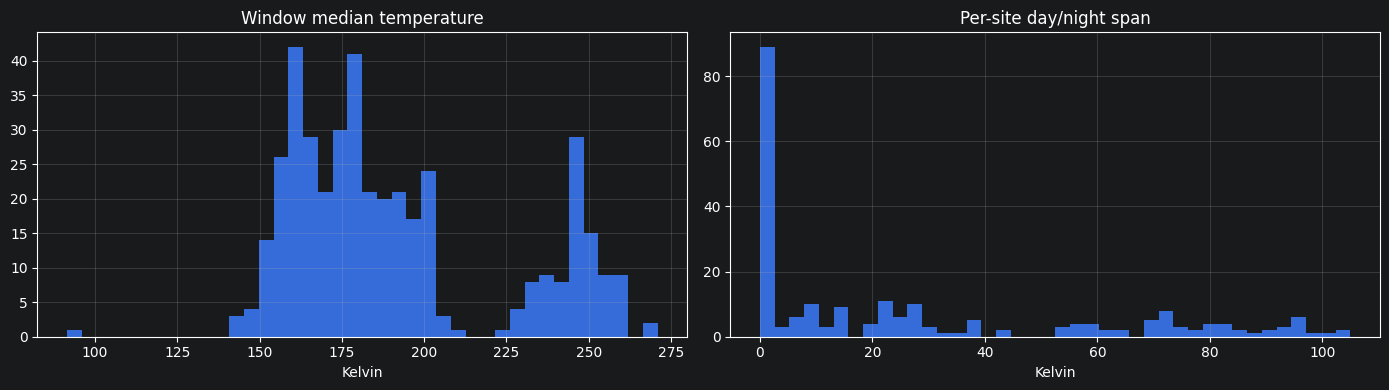

In [18]:
manifest_path = os.path.join(THEMIS_DIR, "window_manifest.json")

if os.path.exists(manifest_path):
    with open(manifest_path) as f:
        manifest = json.load(f)

    frames = pd.DataFrame([
        {"site_id": entry["site_id"], **frame}
        for entry in manifest for frame in entry["frames"]
    ])

    print(f"{len(manifest)} sites, {len(frames)} frames")
    print(f"median valid fraction: {frames.valid_fraction.median():.2f}")
    print(f"sites with any frame <50% valid: "
          f"{frames[frames.valid_fraction < 0.5].site_id.nunique()}")

    span = frames.groupby("site_id")["kelvin_median"].agg(lambda s: s.max() - s.min())
    print(f"\nper-site temperature span (K): median {span.median():.1f}, "
          f"min {span.min():.1f}, max {span.max():.1f}")
    print(f"sites with <10 K span (little diurnal contrast): {(span < 10).sum()}")

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    frames.kelvin_median.hist(bins=40, ax=axs[0])
    axs[0].set_title("Window median temperature")
    axs[0].set_xlabel("Kelvin")
    span.hist(bins=40, ax=axs[1])
    axs[1].set_title("Per-site day/night span")
    axs[1].set_xlabel("Kelvin")
    for ax in axs:
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No windows yet -- run Phase 2 with RUN_PHASE_2 = True.")

## 10. Wiring the windows into training

`Hirise_Dataset` currently fabricates its thermal sequence
(`generate_synthetic_thermal=True`, a `torch.randn` placeholder shaped
`(T, 1, 32, 32)`). To train on the real data, load
`data/thermal_data/themis_data/windows/{site_id}.npy` instead, looking up each
image's `site_id` through `image_coordinates.csv`.

Two things to handle when doing that:

* **Sites with fewer than `T` frames.** Not every site yields a full sequence;
  the dataset returns a fixed `T`, so short sequences need padding, repetition,
  or exclusion. Padding with no-data zeros is the honest option, but keep it
  consistent with how the masked values are normalised.
* **Normalisation.** Mask `0` before any statistic. Prefer contrast within the
  window (pit against its surroundings) over absolute Kelvin: it is the
  physically invariant quantity, and it is robust to season, latitude, and the
  local-time drift across the mission.

The modality ablation in `model/training.ipynb` is the check that this actually
helped -- with the synthetic placeholder, "thermal" scores at chance and "both"
matches "optical". Real windows should move both.